# Task 4: Predicting Insurance Claim Amounts

## Objective
The objective of this project is to estimate medical insurance claim amounts based on demographic and lifestyle factors using a Linear Regression model.

## Dataset
Medical Cost Personal Dataset

## Problem Statement
Insurance companies need accurate estimates of medical costs to assess risk and determine premium pricing. In this project, we build a regression model to predict insurance charges and analyze the factors that contribute most to medical expenses.

## Deliverables
- Data Cleaning and Preparation
- Exploratory Data Analysis (EDA)
- Correlation Analysis
- One-Hot Encoding
- Linear Regression Modeling
- Model Evaluation (MAE, RMSE, R²)
- Feature Importance Interpretation
- Business Insight Generation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Internship DA\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Dataset Description

| Feature | Description |
|----------|------------|
| age | Age of beneficiary |
| sex | Gender |
| bmi | Body Mass Index |
| children | Number of dependents |
| smoker | Smoking status |
| region | Residential region |
| charges | Medical insurance cost (Target Variable) |


## 2. Data Understanding and Quality Checks

In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.describe()


Dataset Shape: (1338, 7)

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


### Observation

- No significant missing values are expected in this dataset.
- Duplicate records are removed to avoid bias during model training.


## 3. Exploratory Data Analysis

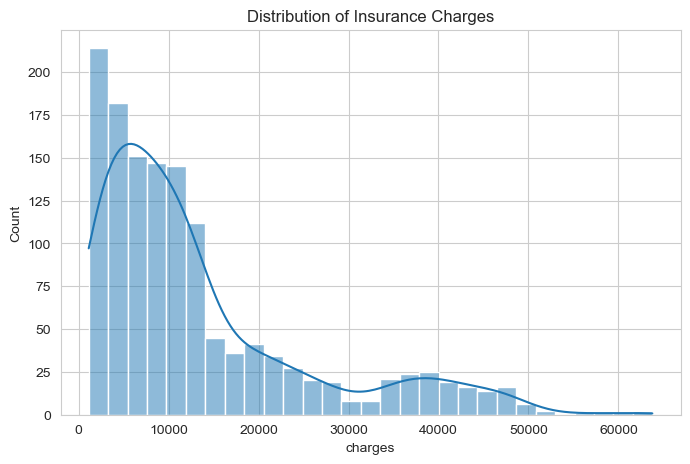

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

### Interpretation

The distribution of insurance charges is positively skewed, indicating that while most customers incur moderate costs, a smaller number generate very high medical expenses.


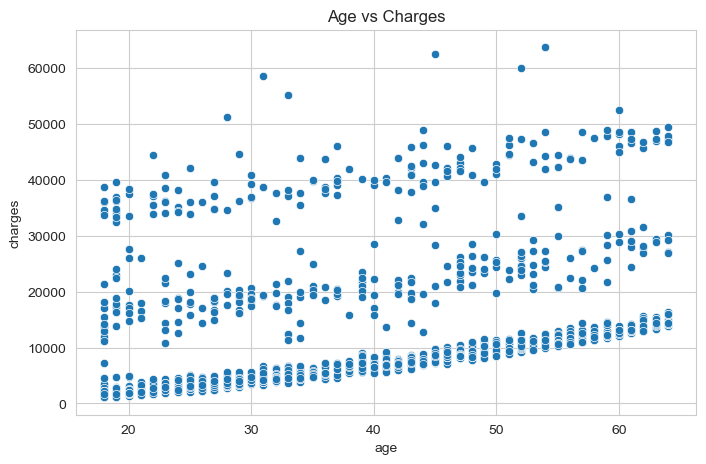

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='age',y='charges')
plt.title('Age vs Charges')
plt.show()

### Interpretation

Insurance costs generally increase with age because older individuals tend to require more medical care and treatments.


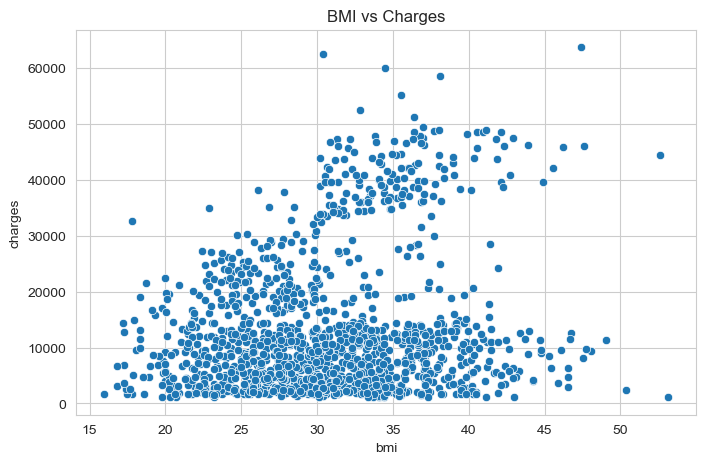

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='bmi',y='charges')
plt.title('BMI vs Charges')
plt.show()

### Interpretation

Higher BMI values are associated with higher medical costs. Individuals with obesity-related health risks often require more medical attention.


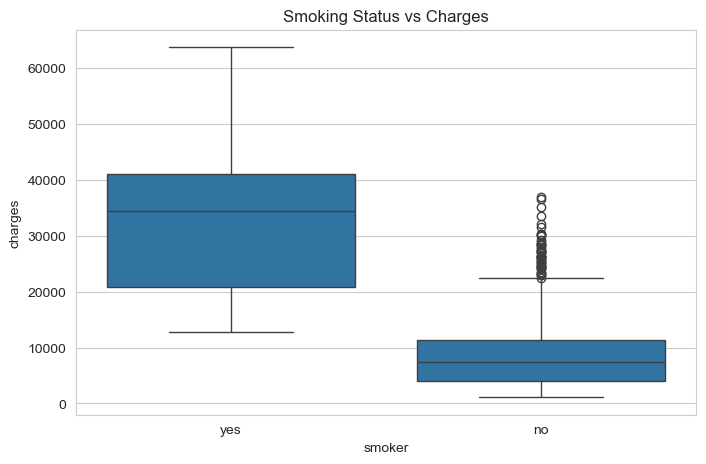

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='smoker',y='charges')
plt.title('Smoking Status vs Charges')
plt.show()

### Interpretation

Smokers exhibit dramatically higher insurance charges compared to non-smokers, suggesting smoking is one of the strongest drivers of healthcare expenses.


## 4. Correlation Analysis

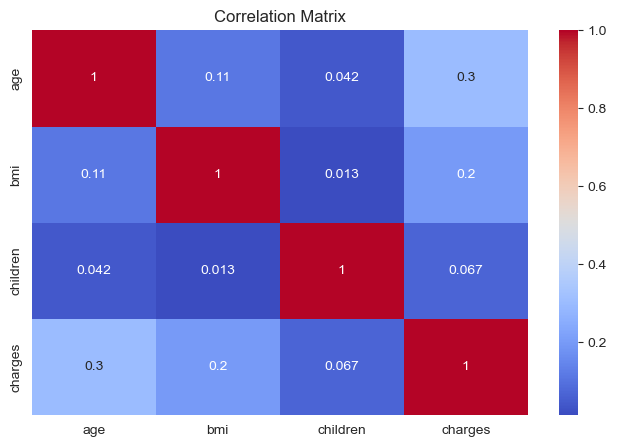

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Interpretation

The correlation matrix helps identify linear relationships among variables.

Key observations:
- Age shows a positive correlation with charges.
- BMI has a moderate positive correlation with charges.
- Children have a weak relationship with insurance costs.


## 5. Data Preprocessing

In [10]:
X = df.drop('charges', axis=1)
y = df['charges']

categorical_features = ['sex','smoker','region']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Why Encoding?

Machine learning algorithms require numerical input. One-Hot Encoding converts categorical values into numerical indicators while avoiding ordinal relationships.


## 6. Linear Regression Model

In [11]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 7. Model Evaluation

In [12]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print('Mean Absolute Error (MAE):', round(mae,2))
print('Root Mean Squared Error (RMSE):', round(rmse,2))
print('R² Score:', round(r2,4))


Mean Absolute Error (MAE): 4177.05
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069


### Evaluation Metrics

**MAE (Mean Absolute Error):**
Average prediction error in actual currency units.

**RMSE (Root Mean Squared Error):**
Measures prediction error while penalizing large mistakes.

**R² Score:**
Represents the proportion of variance explained by the model.


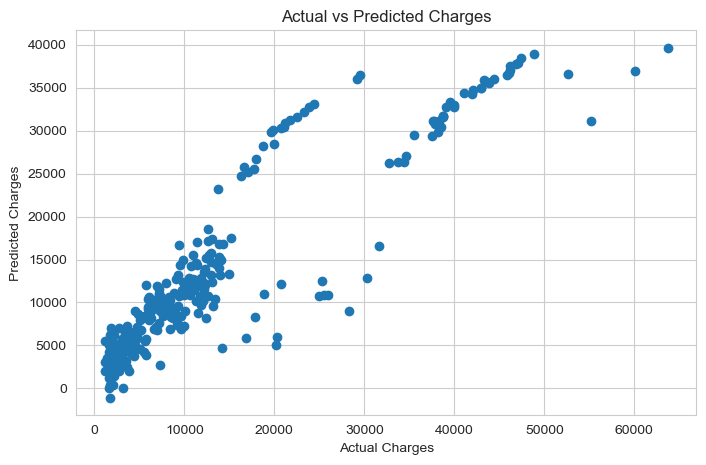

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.show()

### Interpretation

Points closer to the diagonal indicate better predictions. A strong alignment suggests that the model captures the relationship between features and insurance charges effectively.


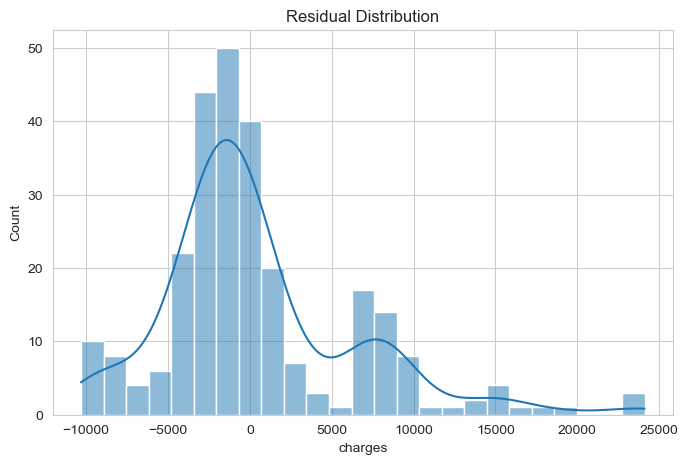

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

### Interpretation

Residuals should ideally be centered around zero. A roughly normal distribution indicates that prediction errors are reasonably balanced.


## 8. Feature Coefficient Interpretation

In [15]:
encoder = model.named_steps['preprocessor']
regressor = model.named_steps['regressor']

feature_names = encoder.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': regressor.coef_
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)
coef_df


,Feature,Coefficient
1,cat__smoker_yes,23077.764593
7,remainder__children,533.009989
6,remainder__bmi,318.701441
5,remainder__age,248.210720
0,cat__sex_male,-101.542054
2,cat__region_northwest,-391.761455
4,cat__region_southwest,-659.139752
3,cat__region_southeast,-838.919616


### Interpretation of Coefficients

- Positive coefficients increase predicted insurance charges.
- Negative coefficients decrease predicted insurance charges.
- Features with larger absolute coefficients have stronger influence on predictions.
- Smoking-related features are expected to have the highest positive impact.


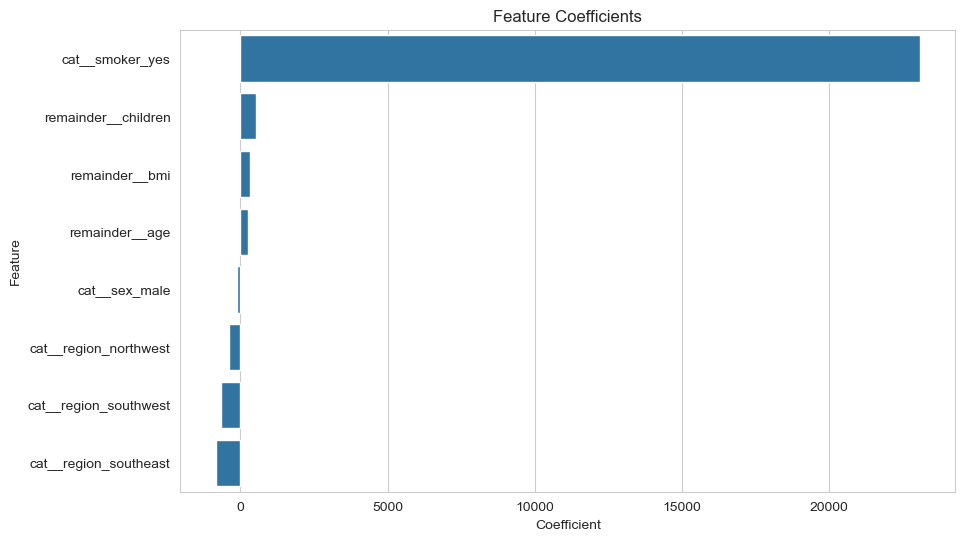

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title('Feature Coefficients')
plt.show()

## 9. Key Findings

### Finding 1: Smoking is the strongest predictor
Smokers generate significantly higher healthcare costs than non-smokers.

### Finding 2: Age impacts charges
Medical costs increase as beneficiaries grow older.

### Finding 3: BMI contributes to cost escalation
Higher BMI values are associated with higher insurance claims.

### Finding 4: Dependents have limited influence
The number of children has relatively small impact compared to smoking and age.


## 10. Business Recommendations

1. Insurance companies should consider smoking status as a major risk factor.
2. Preventive health programs may reduce claims for high-BMI customers.
3. Age-based risk segmentation can improve premium pricing strategies.
4. Customer wellness initiatives can help lower long-term claim expenses.


# Conclusion

A Linear Regression model was successfully developed to predict medical insurance claim amounts.

### Project Achievements
✔ Data cleaning completed

✔ Exploratory analysis performed

✔ BMI, Age, and Smoking impacts visualized

✔ Linear Regression model trained

✔ Performance evaluated using MAE, RMSE, and R²

✔ Feature coefficients interpreted

✔ Business recommendations generated

### Final Summary

The analysis demonstrates that smoking status, age, and BMI are the primary drivers of insurance charges. The Linear Regression model provides a strong baseline solution for estimating future medical insurance costs and supports data-driven decision making for insurance providers.
